# Analiza e Thjeshtuar - Airbnb NYC 2019

Ky notebook është version më i thjeshtë dhe më i lehtë për t'u shpjeguar gjatë prezantimit. Analizat janë mbajtur të qarta: çmimet, zonat, tipi i dhomës, reviews, disponueshmëria dhe hostët.


## 1. Importimi i librarive dhe datasetit


In [36]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

OUTPUT_DIR = Path("../outputs/figures/student_friendly")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv("../data/cleaned_airbnb.csv")
df.head()


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,days_since_last_review
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365,438.0
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355,224.0
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,0.72,1,365,3200.0
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194,179.0
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0,407.0


## 2. Informata bazë për datasetin

Këtu shohim sa rreshta dhe kolona ka dataseti, cilat janë kolonat kryesore dhe disa statistika përmbledhëse.


In [37]:
print("Numri i rreshtave dhe kolonave:", df.shape)
print("\nKolonat:")
print(df.columns.tolist())


Numri i rreshtave dhe kolonave: (45876, 16)

Kolonat:
['id', 'name', 'host_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'days_since_last_review']


In [38]:
df[[
    "price",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "availability_365"
]].describe()


,price,minimum_nights,number_of_reviews,reviews_per_month,availability_365
count,45876.000000,45876.000000,45876.000000,45876.000000,45876.000000
mean,119.999673,6.940884,23.938748,1.249046,109.400100
std,68.128278,19.866529,45.315779,1.539239,130.275539
min,10.000000,1.000000,0.000000,0.010000,0.000000
25%,65.000000,1.000000,1.000000,0.270000,0.000000
50%,100.000000,2.000000,5.000000,0.720000,39.000000
75%,159.000000,5.000000,24.000000,1.620000,217.000000
max,334.000000,1250.000000,629.000000,58.500000,365.000000


## 3. Analiza e çmimeve

Fillimisht shohim si shpërndahen çmimet. Kjo na ndihmon të kuptojmë nëse shumica e listimeve janë të lira, mesatare apo të shtrenjta.


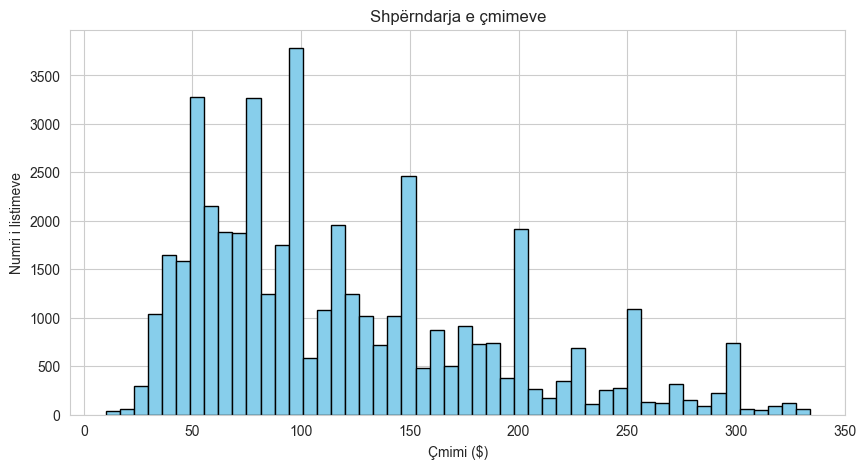

In [39]:
plt.hist(df["price"], bins=50, color="skyblue", edgecolor="black")
plt.title("Shpërndarja e çmimeve")
plt.xlabel("Çmimi ($)")
plt.ylabel("Numri i listimeve")
plt.savefig(OUTPUT_DIR / "01_price_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


**Interpretim:** Shumica e listimeve kanë çmime më të ulëta ose mesatare, ndërsa një numër më i vogël listimesh ka çmime shumë të larta.


## 4. Outliers në çmim

Outliers janë vlera shumë më të larta ose shumë më të ulëta se shumica e të dhënave. Në këtë rast, na interesojnë sidomos listimet me çmime shumë të larta, sepse ato mund ta shtrembërojnë mesataren.


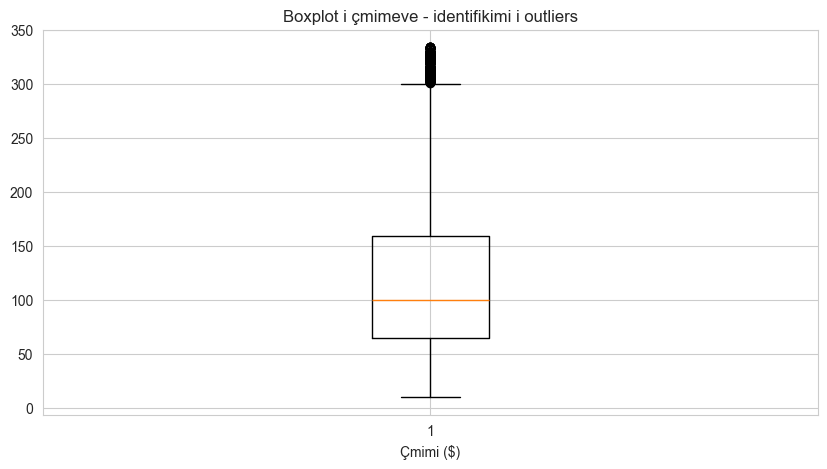

In [40]:
plt.boxplot(df["price"])
plt.title("Boxplot i çmimeve - identifikimi i outliers")
plt.xlabel("Çmimi ($)")
plt.savefig(OUTPUT_DIR / "02_price_outliers_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()


In [41]:
outliers[[
    "name",
    "neighbourhood_group",
    "neighbourhood",
    "room_type",
    "price",
    "number_of_reviews",
    "availability_365"
]].sort_values("price", ascending=False).head(10)


,name,neighbourhood_group,neighbourhood,room_type,price,number_of_reviews,availability_365
2033,1BR Apt as featured in New York Mag,Manhattan,Greenwich Village,Entire home/apt,334,14,238
40907,"Central Herald Sq.1BR w/ Roofdeck, Gym next to...",Manhattan,Midtown,Entire home/apt,334,0,311
36575,Swanky 1BR in Central Chelsea w/ Garden by Blu...,Manhattan,Chelsea,Entire home/apt,334,1,310
36580,"Airy Times Sq 1BR w/ Indoor pool, Gym + Doorma...",Manhattan,Theater District,Entire home/apt,334,0,296
36656,Smart Studio in Heart of West Village w/ Doorm...,Manhattan,West Village,Entire home/apt,334,0,280
23827,Flatiron Loft 3BR/1.5 Bath Best Location\n30 days,Manhattan,Midtown,Entire home/apt,333,66,210
13009,Mid-Century Museum Sleepover,Brooklyn,Williamsburg,Entire home/apt,333,0,365
36470,Parisian Palace in Heart of Manhattan,Manhattan,Chelsea,Entire home/apt,333,4,80
18549,"SOMMwhere in NYC/ a unique, conscious artists ...",Manhattan,Lower East Side,Private room,333,40,62
14292,Midtown Sleep 6 Central Convenience,Manhattan,Midtown,Entire home/apt,333,246,323


**Interpretim:** Outliers në çmim janë listime që kanë çmim shumë më të lartë se shumica e listimeve të tjera. Këto mund të jenë prona luksoze, lokacione shumë të mira, gabime në të dhëna, ose oferta jo tipike. Për analizë më të drejtë, është mirë të raportohet se ekzistojnë dhe të vendoset nëse do të mbahen apo hiqen.


## 5. Çmimi sipas zonës

Krahasojmë çmimet mes zonave kryesore të New York-ut.


In [ ]:
price_by_area = df.groupby("neighbourhood_group")["price"].mean().sort_values(ascending=False)
price_by_area


In [ ]:
price_by_area.plot(kind="bar", color="coral")
plt.title("Çmimi mesatar sipas zonës")
plt.xlabel("Zona")
plt.ylabel("Çmimi mesatar ($)")
plt.xticks(rotation=45)
plt.savefig(OUTPUT_DIR / "03_average_price_by_area.png", dpi=150, bbox_inches="tight")
plt.show()


**Interpretim:** Manhattan zakonisht ka çmime më të larta se zonat tjera, ndërsa Bronx dhe Staten Island janë më ekonomike.


## 6. Çmimi sipas tipit të dhomës

Tipi i dhomës është faktor i rëndësishëm sepse një apartament i plotë pritet të kushtojë më shumë se një dhomë private.


In [ ]:
price_by_room = df.groupby("room_type")["price"].mean().sort_values(ascending=False)
price_by_room


In [ ]:
price_by_room.plot(kind="bar", color="mediumseagreen")
plt.title("Çmimi mesatar sipas tipit të dhomës")
plt.xlabel("Tipi i dhomës")
plt.ylabel("Çmimi mesatar ($)")
plt.xticks(rotation=30)
plt.savefig(OUTPUT_DIR / "04_average_price_by_room_type.png", dpi=150, bbox_inches="tight")
plt.show()


**Interpretim:** Entire home/apt ka çmimin më të lartë mesatar, sepse ofron më shumë privatësi dhe hapësirë.


## 7. Numri i listimeve sipas zonës

Kjo analizë tregon në cilat zona ka më shumë oferta Airbnb.


In [ ]:
listings_by_area = df["neighbourhood_group"].value_counts()
listings_by_area


In [ ]:
listings_by_area.plot(kind="bar", color="steelblue")
plt.title("Numri i listimeve sipas zonës")
plt.xlabel("Zona")
plt.ylabel("Numri i listimeve")
plt.xticks(rotation=45)
plt.savefig(OUTPUT_DIR / "05_listings_by_area.png", dpi=150, bbox_inches="tight")
plt.show()


**Interpretim:** Manhattan dhe Brooklyn kanë numrin më të madh të listimeve, që tregon se këto zona janë më aktive në tregun e Airbnb.


## 8. Reviews dhe aktiviteti i listimeve

Reviews mund të përdoren si tregues i aktivitetit. Më shumë reviews zakonisht nënkupton se listimi është përdorur më shpesh.


In [ ]:
plt.scatter(df["number_of_reviews"], df["price"], alpha=0.3)
plt.title("Çmimi dhe numri i reviews")
plt.xlabel("Numri i reviews")
plt.ylabel("Çmimi ($)")
plt.savefig(OUTPUT_DIR / "06_price_vs_reviews.png", dpi=150, bbox_inches="tight")
plt.show()


**Interpretim:** Nuk shihet lidhje shumë e fortë mes çmimit dhe numrit të reviews. Disa listime të lira kanë shumë reviews, ndërsa disa listime të shtrenjta kanë pak reviews.


## 9. Disponueshmëria gjatë vitit

Kolona `availability_365` tregon për sa ditë gjatë vitit një listim është i disponueshëm.


In [ ]:
plt.hist(df["availability_365"], bins=30, color="plum", edgecolor="black")
plt.title("Disponueshmëria gjatë vitit")
plt.xlabel("Ditë të disponueshme në vit")
plt.ylabel("Numri i listimeve")
plt.savefig(OUTPUT_DIR / "07_availability_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


**Interpretim:** Disa listime janë të disponueshme për shumë ditë gjatë vitit, ndërsa disa të tjera kanë disponueshmëri shumë të ulët. Kjo mund të lidhet me kërkesën, rezervimet ose me faktin që hostët nuk i mbajnë listimet aktive gjatë gjithë vitit.


## 10. Hostët me më shumë listime

Kjo analizë tregon nëse disa hostë kanë shumë prona/listime.


In [ ]:
top_hosts = df["host_id"].value_counts().head(10)
top_hosts


In [ ]:
top_hosts.plot(kind="bar", color="orange")
plt.title("Top 10 hostët me më shumë listime")
plt.xlabel("Host ID")
plt.ylabel("Numri i listimeve")
plt.xticks(rotation=45)
plt.savefig(OUTPUT_DIR / "08_top_hosts.png", dpi=150, bbox_inches="tight")
plt.show()


**Interpretim:** Disa hostë kanë shumë listime, që mund të tregojë se Airbnb përdoret edhe në mënyrë më profesionale/komerciale, jo vetëm nga individë me një pronë.


## 11. Korrelacionet

Korrelacioni tregon nëse dy variabla kanë lidhje me njëra-tjetrën. Vlerat afër 1 ose -1 tregojnë lidhje më të fortë, ndërsa vlerat afër 0 tregojnë lidhje të dobët.


In [ ]:
numeric_cols = [
    "price",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365"
]

corr = df[numeric_cols].corr()
corr


In [ ]:
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Matrica e korrelacionit")
plt.savefig(OUTPUT_DIR / "09_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


**Interpretim:** Korrelacionet nuk janë shumë të forta, që do të thotë se çmimi nuk shpjegohet vetëm nga një faktor. Zona, tipi i dhomës dhe faktorë të tjerë duhen analizuar së bashku.


## 12. Përfundime

- Manhattan është zona më e shtrenjtë mesatarisht.
- Entire home/apt kushton më shumë se private room dhe shared room.
- Manhattan dhe Brooklyn kanë më shumë listime.
- Në çmime ka outliers, prandaj mesatarja duhet interpretuar me kujdes.
- Numri i reviews nuk ka lidhje shumë të fortë me çmimin.
- Disa hostë kanë shumë listime, që tregon prani të operatorëve më profesionalë.
- Për të kuptuar çmimin, duhet të shikohen disa faktorë së bashku: zona, tipi i dhomës, reviews dhe disponueshmëria.
